# Reddit Stance Classifiers — NYC Congestion Pricing (CBDTP)

Three classifiers for **target-directed stance** (`pro` / `anti` / `neutral` / `off-topic`) toward
the toll, trained on the **Sonnet v2 weak labels** and compared on a held-out **validation** set.
Posts and comments are handled by **one** model via a shared `CONTEXT + TARGET` representation.

- **Naive Bayes** — TF-IDF + MultinomialNB (baseline)
- **XGBoost** — sentence embeddings + metadata, class-weighted
- **DistilRoBERTa** — fine-tuned, context truncated / target preserved

**Why `off-topic` is a class, not a filter:** the relevant set (`hp ∪ matched_tier1 ∪ v5`) is frozen
upstream, but ~16% of it is still off-topic (Sonnet v2's read). The model scores items *within* that
fixed set, so `off-topic` is the stance head's 4th outcome — not a relevance recheck.

**Label policy:** `mixed → neutral`, `unsure → neutral`, `NA / not_about_it → off-topic`.
**Splits:** grouped by `link_id` (no thread spans train/val), stratified by label.
**Reporting:** headline 4-class macro-F1 **and** a 3-class macro-F1 on on-topic items (literature-comparable).
**Gold test is gated** by `RUN_TEST` (default `False`) — tune on validation only.

In [2]:
import os
# Use GPU1 (GPU0 drives the display); single GPU is plenty for ~5k rows and avoids DP overhead.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# ============================ TOGGLES ============================
RUN_TEST   = False     # <-- keep False until model tuning is finished. True = run gold test.
SEED       = 42
VAL_FRAC   = 0.15      # fraction of TRAINING threads held out for validation
HF_EPOCHS  = 3         # DistilRoBERTa fine-tuning epochs
HF_MAXLEN  = 256       # token budget (context truncated, target kept)
HF_MODEL   = "distilroberta-base"
EMB_MODEL  = "sentence-transformers/all-MiniLM-L6-v2"
LABELS     = ["anti", "neutral", "pro", "off-topic"]   # 4-class; fixed order for every report
ON_TOPIC   = ["anti", "neutral", "pro"]                # supplementary 3-class (literature-comparable)
STANCE_MAP = {"pro": "pro", "anti": "anti", "neutral": "neutral",
              "mixed": "neutral", "unsure": "neutral",
              "NA": "off-topic", "not_about_it": "off-topic"}
# =================================================================

from pathlib import Path
M2   = Path(r"G:\Other computers\My MacBook Pro\Documents\UM MADS\696 - Milestone 2")
HERE = Path.cwd()
DATA = HERE / "data"

TEXT_XLSX   = M2 / "Project Data - 7 - Relabel 5k" / "relabel_5k_v2.xlsx"
LABEL_CSV   = M2 / "Project Data - 7 - Relabel 5k" / "relabel_5k-claude-v2.csv"
GOLD_JSONL  = DATA / "gold_labels_Anita_301.jsonl"
GOLD_SIDECAR= M2 / "Project Data - 7 - Relabel 5k" / "gold_build" / "gold_adj_sidecar.parquet"

import numpy as np, pandas as pd
np.random.seed(SEED)

## 1. Load training labels + text, apply label policy

Join the Sonnet v2 labels (`relabel_5k-claude-v2.csv`) to the `CONTEXT`/`TARGET` text
(`relabel_5k_v2.xlsx`) on `row_id`. Map stance to 4 classes; off-topic (`NA`) is kept as its
own class (no relevance gate — the relevant set is already frozen upstream).

In [3]:
# keep_default_na=False so the stance string "NA" is not parsed into NaN
text_df  = pd.read_excel(TEXT_XLSX)
label_df = pd.read_csv(LABEL_CSV, keep_default_na=False)

text_cols = ["row_id", "kind", "subreddit", "context", "target"]
df = label_df.merge(text_df[text_cols], on="row_id", how="inner", suffixes=("", "_x"))
print("joined rows:", len(df))

# 4-class stance: off-topic (stance "NA" / not_about_it) becomes its own class
df["label"] = df["claude_v2_stance"].map(STANCE_MAP)
df = df[df["label"].isin(LABELS)].copy()

def build_input(row):
    ctx = "" if pd.isna(row["context"]) else str(row["context"]).strip()
    tgt = "" if pd.isna(row["target"])  else str(row["target"]).strip()
    return (ctx, tgt)

df[["context", "target"]] = df.apply(lambda r: pd.Series(build_input(r)), axis=1)
df["text"] = "[CONTEXT]\n" + df["context"] + "\n\n[TARGET]\n" + df["target"]
df = df[["row_id", "reddit_id", "link_id", "kind", "subreddit", "context", "target", "text", "label"]]
print("after label mapping (4-class):", len(df))
print(df["label"].value_counts())
print(df["kind"].value_counts())

joined rows: 5131
after label mapping (4-class): 5131
label
pro          1971
anti         1379
neutral       985
off-topic     796
Name: count, dtype: int64
kind
comment    4631
post        500
Name: count, dtype: int64


## 2. Remove gold items from training (no leakage)

`gold_labels_Anita_301.jsonl` is keyed by `qid`; the sidecar maps `qid → row_id / reddit_id`.
Any training row that is part of Anita's gold set is dropped so the held-out test stays clean.

In [4]:
import json
gold = pd.DataFrame([json.loads(l) for l in GOLD_JSONL.read_text(encoding="utf-8").splitlines() if l.strip()])
sidecar = pd.read_parquet(GOLD_SIDECAR)[["qid", "row_id", "reddit_id", "cell", "n_cell"]]
gold = gold.merge(sidecar, on="qid", how="left")

gold_row_ids    = set(gold["row_id"].dropna())
gold_reddit_ids = set(gold["reddit_id"].dropna())
before = len(df)
df = df[~df["row_id"].isin(gold_row_ids) & ~df["reddit_id"].isin(gold_reddit_ids)].copy()
print(f"dropped {before - len(df)} gold rows; training rows now {len(df)}")
print("gold items labeled by Anita:", len(gold))

dropped 301 gold rows; training rows now 4830
gold items labeled by Anita: 301


## 3. Grouped + stratified split into train / validation

Split on `link_id` so a thread never spans both sides (prevents context leakage),
while keeping the stance distribution balanced via `StratifiedGroupKFold`.

In [5]:
from sklearn.model_selection import StratifiedGroupKFold
n_splits = max(2, round(1 / VAL_FRAC))
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
groups = df["link_id"].fillna(df["row_id"])          # posts: fall back to own id
tr_idx, va_idx = next(sgkf.split(df, df["label"], groups))
train, val = df.iloc[tr_idx].copy(), df.iloc[va_idx].copy()

assert set(train["link_id"]).isdisjoint(set(val["link_id"]) - {np.nan}), "thread leak!"
print(f"train={len(train)}  val={len(val)}")
print(pd.concat([train["label"].value_counts().rename("train"),
                 val["label"].value_counts().rename("val")], axis=1))

train=4140  val=690
           train  val
label                
pro         1592  265
anti        1107  185
neutral      800  133
off-topic    641  107


## 4. Build the (gated) gold test set

Anita's labels joined to the same `CONTEXT/TARGET` text. `mixed → neutral`, `NA → off-topic`
(all 4 classes kept). Population weights `w = n_cell / n_labeled_in_cell` undo the
disagreement-oversampling so the TEST numbers are population-representative.
Materialized now for convenience but **only consumed in the final gated cell**.

In [20]:
gold_text = gold.merge(
    text_df[text_cols].drop(columns=[c for c in text_cols if c in gold.columns and c != "row_id"]),
    on="row_id", how="left")
gold_text["label"] = gold_text["label"].map(STANCE_MAP)
gold_text = gold_text[gold_text["label"].isin(LABELS)].copy()
gold_text["context"] = gold_text["context"].fillna("").astype(str).str.strip()
gold_text["target"]  = gold_text["target"].fillna("").astype(str).str.strip()
gold_text["text"] = "[CONTEXT]\n" + gold_text["context"] + "\n\n[TARGET]\n" + gold_text["target"]
# population reweighting: each cell was sampled at n_labeled/n_cell, so w = n_cell / n_labeled
gold_text["w"] = gold_text["n_cell"] / gold_text.groupby("cell")["qid"].transform("count")
print(f"gold test items (4-class): {len(gold_text)}")
# Gold label distribution intentionally NOT printed — keep the gold set blind during tuning
# so it cannot influence model/threshold choices. Only the total row count is shown.
# print(gold_text["label"].value_counts())

gold test items (4-class): 301


## 5. Single evaluation harness

One function used identically for every model and split — macro-F1 (headline metric),
per-class precision/recall/F1, and the confusion matrix.

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt, seaborn as sns

RESULTS = []   # collected (model, split, metrics)

def evaluate(model_name, split_name, y_true, y_pred, sample_weight=None, show_cm=True):
    y_true = pd.Series(list(y_true)).reset_index(drop=True)
    y_pred = pd.Series(list(y_pred)).reset_index(drop=True)
    sw = None if sample_weight is None else np.asarray(sample_weight, dtype=float)
    macro_f1 = f1_score(y_true, y_pred, labels=LABELS, average="macro", sample_weight=sw, zero_division=0)
    acc = accuracy_score(y_true, y_pred, sample_weight=sw)
    # supplementary 3-class metric on truly on-topic items (literature-comparable); an
    # off-topic *prediction* on these items simply counts as an error for every stance class.
    m = y_true.isin(ON_TOPIC).to_numpy()
    sw_m = None if sw is None else sw[m]
    f1_3 = (f1_score(y_true[m], y_pred[m], labels=ON_TOPIC, average="macro", sample_weight=sw_m, zero_division=0)
            if m.any() else float("nan"))
    tag = " (pop-weighted)" if sw is not None else ""
    print(f"\n=== {model_name} · {split_name}{tag} ===  "
          f"macroF1[4]={macro_f1:.3f}  macroF1[3 on-topic]={f1_3:.3f}  acc={acc:.3f}")
    print(classification_report(y_true, y_pred, labels=LABELS, digits=3, sample_weight=sw, zero_division=0))
    if show_cm:
        cm = confusion_matrix(y_true, y_pred, labels=LABELS, sample_weight=sw)
        plt.figure(figsize=(4, 3.4))
        sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS, cbar=False)
        plt.xlabel("predicted"); plt.ylabel("true"); plt.title(f"{model_name} · {split_name}"); plt.tight_layout(); plt.show()
    rec = {"model": model_name, "split": split_name,
           "macro_f1": macro_f1, "macro_f1_3class": f1_3, "accuracy": acc}
    for lbl in LABELS:
        rec[f"f1_{lbl}"] = f1_score(y_true, y_pred, labels=[lbl], average="macro", sample_weight=sw, zero_division=0)
    RESULTS.append(rec)
    return rec

def class_weights(y):
    vc = pd.Series(y).value_counts()
    n, k = len(y), len(vc)
    return {c: n / (k * vc[c]) for c in vc.index}

## 6. Model 1 — Naive Bayes (TF-IDF baseline)

`ComplementNB` (built for imbalanced text, unlike `MultinomialNB` which here collapsed onto the
majority class). The TARGET and CONTEXT are vectorized separately so the long ancestor context
doesn't drown the item being labeled — context is down-weighted to 0.3.


=== NaiveBayes · val ===  macroF1[4]=0.418  macroF1[3 on-topic]=0.541  acc=0.503
              precision    recall  f1-score   support

        anti      0.512     0.335     0.405       185
     neutral      0.663     0.414     0.509       133
         pro      0.472     0.830     0.602       265
   off-topic      0.500     0.093     0.157       107

    accuracy                          0.503       690
   macro avg      0.537     0.418     0.418       690
weighted avg      0.524     0.503     0.462       690



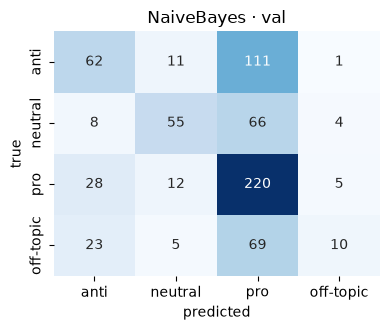

{'model': 'NaiveBayes',
 'split': 'val',
 'macro_f1': 0.4184708792670866,
 'macro_f1_3class': 0.5413807087878172,
 'accuracy': 0.5028985507246376,
 'f1_anti': 0.40522875816993464,
 'f1_neutral': 0.5092592592592593,
 'f1_pro': 0.6019151846785226,
 'f1_off-topic': 0.15748031496062992}

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

nb_cols = ["target", "context"]
nb = Pipeline([
    ("feats", ColumnTransformer([
        ("tgt", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True,
                                strip_accents="unicode"), "target"),
        ("ctx", TfidfVectorizer(ngram_range=(1, 2), min_df=3, sublinear_tf=True,
                                strip_accents="unicode"), "context"),
    ], transformer_weights={"tgt": 1.0, "ctx": 0.3})),
    ("clf", ComplementNB(alpha=0.3)),
])
nb.fit(train[nb_cols], train["label"])
evaluate("NaiveBayes", "val", val["label"], nb.predict(val[nb_cols]))

## 7. Model 2 — XGBoost (embeddings + metadata, class-weighted)

Features: MiniLM sentence embeddings of the serialized text, plus light metadata
(`is_post`, log text length). Sample-weighted to offset class imbalance.

c:\Users\Freya\.venvs\mads-m2-classifiers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5476.70it/s]



=== XGBoost · val ===  macroF1[4]=0.447  macroF1[3 on-topic]=0.510  acc=0.483
              precision    recall  f1-score   support

        anti      0.482     0.427     0.453       185
     neutral      0.468     0.383     0.421       133
         pro      0.504     0.645     0.566       265
   off-topic      0.410     0.299     0.346       107

    accuracy                          0.483       690
   macro avg      0.466     0.439     0.447       690
weighted avg      0.477     0.483     0.474       690



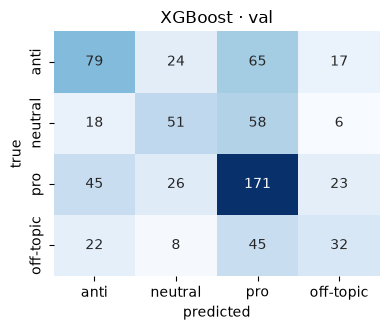

{'model': 'XGBoost',
 'split': 'val',
 'macro_f1': 0.4465951944629736,
 'macro_f1_3class': 0.5102948872951006,
 'accuracy': 0.4826086956521739,
 'f1_anti': 0.45272206303724927,
 'f1_neutral': 0.4214876033057851,
 'f1_pro': 0.5662251655629139,
 'f1_off-topic': 0.34594594594594597}

In [9]:
from sentence_transformers import SentenceTransformer
import xgboost as xgb

embedder = SentenceTransformer(EMB_MODEL, device="cuda")
def embed(texts):
    return embedder.encode(list(texts), batch_size=128, show_progress_bar=False,
                           convert_to_numpy=True, normalize_embeddings=True)

def meta(frame):
    is_post = (frame["kind"] == "post").to_numpy().astype("float32")[:, None]
    loglen  = np.log1p(frame["target"].str.len().to_numpy()).astype("float32")[:, None]
    return np.hstack([is_post, loglen])

Xtr = np.hstack([embed(train["text"]), meta(train)])
Xva = np.hstack([embed(val["text"]),   meta(val)])
lab2i = {l: i for i, l in enumerate(LABELS)}
ytr = train["label"].map(lab2i).to_numpy()
yva = val["label"].map(lab2i).to_numpy()

cw = class_weights(train["label"]); w = train["label"].map(cw).to_numpy()
clf = xgb.XGBClassifier(
    n_estimators=800, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=2,
    objective="multi:softprob", num_class=len(LABELS),
    tree_method="hist", device="cuda", eval_metric="mlogloss",
    early_stopping_rounds=40, random_state=SEED,
)
clf.fit(Xtr, ytr, sample_weight=w, eval_set=[(Xva, yva)], verbose=False)
clf.get_booster().set_param({"device": "cpu"})   # predict on CPU (tiny data); avoids device-mismatch warning
i2lab = {i: l for l, i in lab2i.items()}
evaluate("XGBoost", "val", val["label"], pd.Series(clf.predict(Xva)).map(i2lab))

## 8. Model 3 — DistilRoBERTa (fine-tuned, class-weighted)

The target sits at the **end** of the serialized text, so `truncation_side="left"` drops
context first and **always preserves the target** (its tail if the target itself is long) —
and never errors on long targets. Weighted cross-entropy handles imbalance.

Loading weights: 100%|██████████| 101/101 [00:00<00:00, 5727.37it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_rati

Epoch,Training Loss,Validation Loss,Macro F1
1,1.364525,1.302198,0.350091
2,1.194072,1.161253,0.459415
3,1.063982,1.128427,0.485820


Map: 100%|██████████| 690/690 [00:00<00:00, 2284.45 examples/s]



=== DistilRoBERTa · val ===  macroF1[4]=0.486  macroF1[3 on-topic]=0.552  acc=0.493
              precision    recall  f1-score   support

        anti      0.520     0.573     0.545       185
     neutral      0.473     0.647     0.546       133
         pro      0.633     0.377     0.473       265
   off-topic      0.329     0.449     0.379       107

    accuracy                          0.493       690
   macro avg      0.488     0.511     0.486       690
weighted avg      0.524     0.493     0.492       690



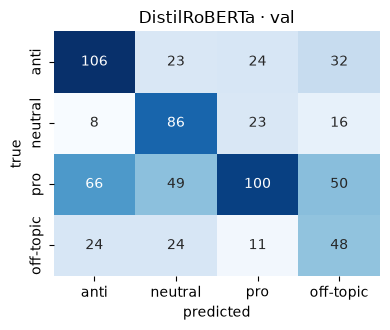

{'model': 'DistilRoBERTa',
 'split': 'val',
 'macro_f1': 0.48581969291205,
 'macro_f1_3class': 0.5524413677027742,
 'accuracy': 0.4927536231884058,
 'f1_anti': 0.5449871465295629,
 'f1_neutral': 0.546031746031746,
 'f1_pro': 0.4728132387706856,
 'f1_off-topic': 0.3794466403162055}

In [10]:
import torch
from torch import nn
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)

tok = AutoTokenizer.from_pretrained(HF_MODEL)
tok.truncation_side = "left"          # keep the target (end of the string); drop context first
def to_ds(frame):
    d = Dataset.from_dict({"text":   frame["text"].tolist(),
                           "labels": frame["label"].map(lab2i).tolist()})
    return d.map(lambda b: tok(b["text"], truncation=True, max_length=HF_MAXLEN), batched=True)
ds_tr, ds_va = to_ds(train), to_ds(val)

wt = torch.tensor([class_weights(train["label"])[l] for l in LABELS], dtype=torch.float)
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kw):
        labels = inputs.pop("labels")
        out = model(**inputs)
        loss = nn.functional.cross_entropy(out.logits, labels, weight=wt.to(out.logits.device))
        return (loss, out) if return_outputs else loss

def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    return {"macro_f1": f1_score(p.label_ids, preds, average="macro", zero_division=0)}

model = AutoModelForSequenceClassification.from_pretrained(
    HF_MODEL, num_labels=len(LABELS),
    id2label={i: l for i, l in enumerate(LABELS)}, label2id=lab2i)

args = TrainingArguments(
    output_dir=str(HERE / "_hf_out"), num_train_epochs=HF_EPOCHS,
    per_device_train_batch_size=32, per_device_eval_batch_size=64,
    learning_rate=2e-5, warmup_ratio=0.1, weight_decay=0.01,
    eval_strategy="epoch", save_strategy="no", logging_steps=50,
    fp16=True, seed=SEED, report_to="none", dataloader_pin_memory=False,
)
trainer = WeightedTrainer(model=model, args=args, train_dataset=ds_tr, eval_dataset=ds_va,
                          processing_class=tok, data_collator=DataCollatorWithPadding(tok),
                          compute_metrics=compute_metrics)
trainer.train()

def hf_predict(frame):
    ds = to_ds(frame)
    logits = trainer.predict(ds).predictions
    return pd.Series(logits.argmax(-1)).map(i2lab)

evaluate("DistilRoBERTa", "val", val["label"], hf_predict(val))

## 9. Validation comparison

,split,macro_f1,macro_f1_3class,accuracy,f1_anti,f1_neutral,f1_pro,f1_off-topic
model,,,,,,,,
NaiveBayes,val,0.418,0.541,0.503,0.405,0.509,0.602,0.157
XGBoost,val,0.447,0.510,0.483,0.453,0.421,0.566,0.346
DistilRoBERTa,val,0.486,0.552,0.493,0.545,0.546,0.473,0.379


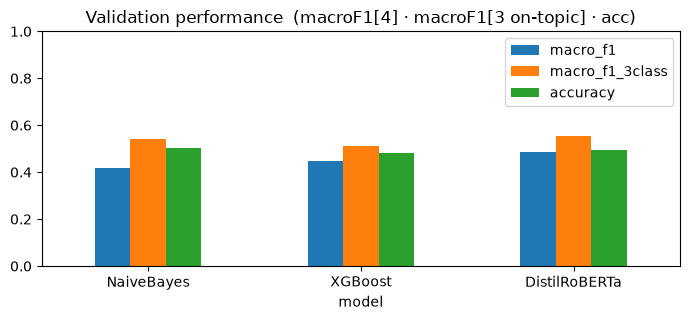

In [11]:
res = pd.DataFrame([r for r in RESULTS if r["split"] == "val"]).set_index("model")
display(res.round(3))
res[["macro_f1", "macro_f1_3class", "accuracy"]].plot.bar(rot=0, figsize=(7, 3.3), ylim=(0, 1));
plt.title("Validation performance  (macroF1[4] · macroF1[3 on-topic] · acc)")
plt.tight_layout(); plt.show()

## 10. Hyperparameter tuning — grouped-CV + Optuna/ASHA (gold untouched)

A separate, additive tuning pass; the baselines above are the untuned "v0" rows.

- **NB / XGBoost:** selected by **3-fold `StratifiedGroupKFold`** (grouped by `link_id`) mean macro-F1.
- **Transformers (ModernBERT @1024, DistilRoBERTa @512):** Optuna + **ASHA pruning** on the grouped
  train/val split, reporting per-epoch val macro-F1 (k-fold transformer search is too costly). Their
  `val-tuned` number is therefore mildly optimistic (selected on the same val) — the **gold test is the
  arbiter**. NB/XGBoost use true CV, so theirs is clean.
- Every trial persists to `tuning_studies.db` (SQLite) — that study **is** the logged ablation.
- Knobs are env-overridable (`TUNE_TRIALS_XGB`, `TUNE_TRIALS_TF`, `TUNE_MAX_EPOCHS`, `TUNE_FOLDS`) for
  quick smoke runs. Transformers run on GPU1.

In [12]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS_XGB = int(os.environ.get("TUNE_TRIALS_XGB", 30))
N_TRIALS_TF  = int(os.environ.get("TUNE_TRIALS_TF",  20))
MAX_EPOCHS   = int(os.environ.get("TUNE_MAX_EPOCHS", 4))
CV_FOLDS     = int(os.environ.get("TUNE_FOLDS", 3))
STUDY_DB     = f"sqlite:///{(HERE / 'tuning_studies.db').as_posix()}"
(HERE / "tuning_studies.db").unlink(missing_ok=True)   # fresh studies each full run
cv = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
g_train = train["link_id"].fillna(train["row_id"]).to_numpy()
TUNED = {}     # name -> predict_fn(frame) -> label Series

# Saved-model paths (each model cell loads if present, else trains + saves -> reusable in the
# corpus-labeling notebook). ModernBERT loads the ORIGINAL save and only writes a _v2 copy if
# it has to retrain, so the existing modernbert_stance is never overwritten.
SAVED = HERE / "saved_models"; SAVED.mkdir(exist_ok=True)
NB_PATH   = SAVED / "nb_complementnb.joblib"
XGB_PATH  = SAVED / "xgb_stance.json"
DR_DIR    = SAVED / "distilroberta_stance"
MB_DIR    = SAVED / "modernbert_stance"        # original (load target)
MB_DIR_V2 = SAVED / "modernbert_stance_v2"     # written only if ModernBERT is retrained
print(f"tuning: folds={CV_FOLDS}  xgb_trials={N_TRIALS_XGB}  tf_trials={N_TRIALS_TF}  max_epochs={MAX_EPOCHS}")

tuning: folds=3  xgb_trials=30  tf_trials=20  max_epochs=4


### 10a. Naive Bayes — GridSearchCV (grouped)

NB best: {'clf__alpha': 0.1, 'feats__tgt__ngram_range': (1, 2), 'feats__transformer_weights': {'tgt': 1.0, 'ctx': 0.6}}  cv macro-F1 = 0.424
NaiveBayes: saved to g:\Other computers\My MacBook Pro\Documents\UM MADS\696 - Milestone 2\Project Data - 11 - Classifiers\saved_models\nb_complementnb.joblib

=== NaiveBayes (tuned) · val-tuned ===  macroF1[4]=0.449  macroF1[3 on-topic]=0.539  acc=0.493
              precision    recall  f1-score   support

        anti      0.458     0.411     0.433       185
     neutral      0.508     0.474     0.490       133
         pro      0.524     0.668     0.587       265
   off-topic      0.387     0.224     0.284       107

    accuracy                          0.493       690
   macro avg      0.469     0.444     0.449       690
weighted avg      0.482     0.493     0.480       690



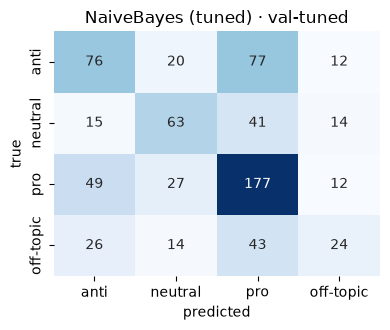

In [13]:
from sklearn.model_selection import GridSearchCV
nb_grid = {
    "feats__tgt__ngram_range":   [(1, 1), (1, 2)],
    "feats__transformer_weights": [{"tgt": 1.0, "ctx": 0.3}, {"tgt": 1.0, "ctx": 0.6}, {"tgt": 1.0, "ctx": 1.0}],
    "clf__alpha":                [0.1, 0.3, 1.0],
}
import joblib
if NB_PATH.exists():
    nb_best = joblib.load(NB_PATH); print("NaiveBayes: loaded from", NB_PATH, "(skipped GridSearch)")
else:
    gs = GridSearchCV(nb, nb_grid, scoring="f1_macro", cv=cv, n_jobs=-1, refit=True)
    gs.fit(train[nb_cols], train["label"], groups=g_train)
    nb_best = gs.best_estimator_
    print("NB best:", gs.best_params_, " cv macro-F1 =", round(gs.best_score_, 3))
    joblib.dump(nb_best, NB_PATH); print("NaiveBayes: saved to", NB_PATH)
evaluate("NaiveBayes (tuned)", "val-tuned", val["label"], nb_best.predict(val[nb_cols]))
TUNED["NaiveBayes"] = lambda X: pd.Series(nb_best.predict(X[nb_cols]), index=X.index)

### 10b. XGBoost — feature upgrade **then** Optuna over tree params (grouped 3-fold CV)

XGBoost's bottleneck is features, not tree knobs, so the tuned model gets an upgraded feature set
(vs the MiniLM+meta baseline): **stronger `bge-base` embeddings + the sentiment columns** (joined by
`reddit_id`; unscored items → NaN, which XGBoost handles natively) **+ metadata**. Tree
hyperparameters are then tuned by grouped 3-fold CV on top of these features.

sentiment features: 152 numeric cols covering 463,501 ids


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4961.40it/s]


XGBoost feature dim: 922
XGB best: {'max_depth': 6, 'learning_rate': 0.024996765783023695, 'min_child_weight': 8, 'subsample': 0.6433453521490261, 'colsample_bytree': 0.8887644218011379, 'gamma': 3.186738158151463, 'reg_lambda': 2.8208865304967796}  cv macro-F1 = 0.496
XGBoost: saved to g:\Other computers\My MacBook Pro\Documents\UM MADS\696 - Milestone 2\Project Data - 11 - Classifiers\saved_models\xgb_stance.json

=== XGBoost (tuned) · val-tuned ===  macroF1[4]=0.509  macroF1[3 on-topic]=0.584  acc=0.529
              precision    recall  f1-score   support

        anti      0.559     0.611     0.584       185
     neutral      0.508     0.496     0.502       133
         pro      0.609     0.536     0.570       265
   off-topic      0.352     0.411     0.379       107

    accuracy                          0.529       690
   macro avg      0.507     0.514     0.509       690
weighted avg      0.536     0.529     0.531       690



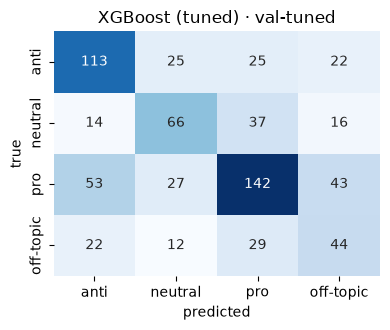

In [14]:
from sentence_transformers import SentenceTransformer
SENT_DIR = M2 / "Project Data - 4 - Sentiment" / "sentiment_snapshot_2026-06-15"
_sent = pd.concat([pd.read_parquet(SENT_DIR / "comment_sentiment.parquet"),
                   pd.read_parquet(SENT_DIR / "post_sentiment.parquet")], ignore_index=True)
_num_cols = [c for c in _sent.select_dtypes(include="number").columns if c != "id"]
sent_feats = _sent.drop_duplicates("id").set_index("id")[_num_cols]
print(f"sentiment features: {len(_num_cols)} numeric cols covering {sent_feats.index.nunique():,} ids")

strong_embedder = SentenceTransformer("BAAI/bge-base-en-v1.5", device="cuda")
def strong_embed(texts):
    return strong_embedder.encode(list(texts), batch_size=128, show_progress_bar=False,
                                  convert_to_numpy=True, normalize_embeddings=True)

def xgb_feats(frame):
    emb = strong_embed(frame["text"])
    mt  = meta(frame)
    sf  = sent_feats.reindex(frame["reddit_id"]).to_numpy(dtype="float32")   # NaN if unscored
    return np.hstack([emb, mt, sf]).astype("float32")

# precompute upgraded features once (frozen encoder + static sentiment -> no leakage)
Xall = xgb_feats(train); yall = train["label"].map(lab2i).to_numpy()
Xval = xgb_feats(val);   yval = val["label"].map(lab2i).to_numpy()
print("XGBoost feature dim:", Xall.shape[1])
folds = list(cv.split(Xall, yall, groups=g_train))

def xgb_objective(trial):
    p = dict(
        max_depth=trial.suggest_int("max_depth", 3, 9),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 8),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    )
    sc = []
    for tr_i, va_i in folds:
        cwd = class_weights(pd.Series(yall[tr_i])); sw = pd.Series(yall[tr_i]).map(cwd).to_numpy()
        m = xgb.XGBClassifier(**p, n_estimators=1000, objective="multi:softprob", num_class=len(LABELS),
                              tree_method="hist", device="cuda", eval_metric="mlogloss",
                              early_stopping_rounds=30, random_state=SEED)
        m.fit(Xall[tr_i], yall[tr_i], sample_weight=sw, eval_set=[(Xall[va_i], yall[va_i])], verbose=False)
        m.get_booster().set_param({"device": "cpu"})
        sc.append(f1_score(yall[va_i], m.predict(Xall[va_i]), average="macro", zero_division=0))
    return float(np.mean(sc))

if XGB_PATH.exists():
    xgb_best = xgb.XGBClassifier(); xgb_best.load_model(str(XGB_PATH))
    print("XGBoost: loaded from", XGB_PATH, "(skipped Optuna)")
else:
    study_xgb = optuna.create_study(direction="maximize", study_name="xgb", storage=STUDY_DB,
                                    load_if_exists=True, sampler=optuna.samplers.TPESampler(seed=SEED))
    study_xgb.optimize(xgb_objective, n_trials=N_TRIALS_XGB)
    print("XGB best:", study_xgb.best_params, " cv macro-F1 =", round(study_xgb.best_value, 3))
    cwd = class_weights(train["label"]); sw = train["label"].map(cwd).to_numpy()
    xgb_best = xgb.XGBClassifier(**study_xgb.best_params, n_estimators=1000, objective="multi:softprob",
                num_class=len(LABELS), tree_method="hist", device="cuda", eval_metric="mlogloss",
                early_stopping_rounds=30, random_state=SEED)
    xgb_best.fit(Xall, yall, sample_weight=sw, eval_set=[(Xval, yval)], verbose=False)
    xgb_best.save_model(str(XGB_PATH)); print("XGBoost: saved to", XGB_PATH)
xgb_best.get_booster().set_param({"device": "cpu"})
evaluate("XGBoost (tuned)", "val-tuned", val["label"], pd.Series(xgb_best.predict(Xval)).map(i2lab))
TUNED["XGBoost"] = lambda X: pd.Series(xgb_best.predict(xgb_feats(X)), index=X.index).map(i2lab)

### 10c. Transformers — Optuna + ASHA (ModernBERT @1024, DistilRoBERTa @512)

Loading weights: 100%|██████████| 138/138 [00:00<00:00, 3165.06it/s]


ModernBERT@1024: loaded from g:\Other computers\My MacBook Pro\Documents\UM MADS\696 - Milestone 2\Project Data - 11 - Classifiers\saved_models\modernbert_stance (skipped training)

=== ModernBERT@1024 · val-tuned ===  macroF1[4]=0.537  macroF1[3 on-topic]=0.617  acc=0.557
              precision    recall  f1-score   support

        anti      0.612     0.562     0.586       185
     neutral      0.554     0.579     0.566       133
         pro      0.608     0.596     0.602       265
   off-topic      0.372     0.421     0.395       107

    accuracy                          0.557       690
   macro avg      0.536     0.539     0.537       690
weighted avg      0.562     0.557     0.559       690



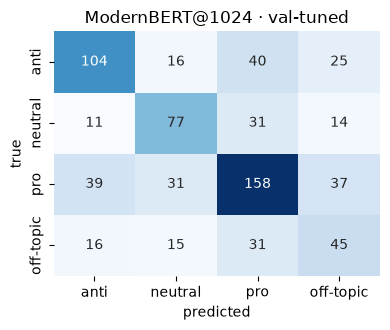

In [15]:
from torch.utils.data import DataLoader
DEV = "cuda"
wt_tf = torch.tensor([class_weights(train["label"])[l] for l in LABELS], dtype=torch.float)

def _loader(frame, tk, max_len, bs, shuffle):
    enc = tk(frame["text"].tolist(), truncation=True, max_length=max_len)
    rows = [{"input_ids": ii, "labels": y} for ii, y in zip(enc["input_ids"], frame["label"].map(lab2i).tolist())]
    return DataLoader(rows, batch_size=bs, shuffle=shuffle, collate_fn=DataCollatorWithPadding(tk))

def _predict_tf(model, tk, frame, max_len, bs=64):
    enc = tk(frame["text"].tolist(), truncation=True, max_length=max_len)
    dl = DataLoader([{"input_ids": ii} for ii in enc["input_ids"]], batch_size=bs, shuffle=False,
                    collate_fn=DataCollatorWithPadding(tk))
    model.eval(); out = []
    with torch.no_grad():
        for b in dl:
            b = {k: v.to(DEV) for k, v in b.items()}
            with torch.autocast("cuda", dtype=torch.bfloat16):
                logits = model(**b).logits
            out.append(logits.argmax(-1).cpu())
    return pd.Series(torch.cat(out).numpy(), index=frame.index).map(i2lab)

def _train_tf(model_name, max_len, bs, lr, wd, warmup_ratio, epochs, trial=None):
    tk = AutoTokenizer.from_pretrained(model_name); tk.truncation_side = "left"
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=len(LABELS),
        id2label={i: l for i, l in enumerate(LABELS)}, label2id=lab2i).to(DEV)
    dl_tr = _loader(train, tk, max_len, bs, True)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    total = max(1, len(dl_tr) * epochs); warm = int(total * warmup_ratio)
    sched = torch.optim.lr_scheduler.LambdaLR(
        opt, lambda s: s / max(1, warm) if s < warm else max(0.0, (total - s) / max(1, total - warm)))
    w = wt_tf.to(DEV); best = 0.0
    for ep in range(epochs):
        model.train()
        for b in dl_tr:
            y = b.pop("labels").to(DEV); b = {k: v.to(DEV) for k, v in b.items()}
            with torch.autocast("cuda", dtype=torch.bfloat16):
                loss = nn.functional.cross_entropy(model(**b).logits, y, weight=w)
            loss.backward(); opt.step(); sched.step(); opt.zero_grad()
        f1 = f1_score(val["label"], _predict_tf(model, tk, val, max_len), labels=LABELS,
                      average="macro", zero_division=0)
        best = max(best, f1)
        if trial is not None:
            trial.report(f1, ep)
            if trial.should_prune():
                del model, opt; torch.cuda.empty_cache(); raise optuna.TrialPruned()
    return model, tk, best

def run_tf(name, model_name, max_len, bs, save_dir, load_dir=None):
    # Load the model if a saved copy exists (skip training); otherwise Optuna+ASHA tune,
    # train the best config, and save it (saving happens right after training).
    load_dir = Path(load_dir or save_dir)
    if load_dir.exists():
        tk = AutoTokenizer.from_pretrained(load_dir); tk.truncation_side = "left"
        model = AutoModelForSequenceClassification.from_pretrained(load_dir).to(DEV)
        print(f"{name}: loaded from {load_dir} (skipped training)")
    else:
        def obj(trial):
            _, _, best = _train_tf(model_name, max_len, bs,
                lr=trial.suggest_float("lr", 1e-5, 5e-5, log=True),
                wd=trial.suggest_float("weight_decay", 0.0, 0.1),
                warmup_ratio=trial.suggest_float("warmup_ratio", 0.0, 0.2),
                epochs=MAX_EPOCHS, trial=trial)
            return best
        study = optuna.create_study(direction="maximize", study_name=name, storage=STUDY_DB,
            load_if_exists=True, sampler=optuna.samplers.TPESampler(seed=SEED),
            pruner=optuna.pruners.SuccessiveHalvingPruner())
        study.optimize(obj, n_trials=N_TRIALS_TF)
        bp = study.best_params
        print(f"{name} best:", {k: round(v, 6) for k, v in bp.items()}, " val macro-F1 =", round(study.best_value, 3))
        model, tk, _ = _train_tf(model_name, max_len, bs, bp["lr"], bp["weight_decay"], bp["warmup_ratio"], MAX_EPOCHS)
        import json
        save_dir = Path(save_dir); save_dir.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(save_dir); tk.save_pretrained(save_dir)
        json.dump({"max_len": max_len, "truncation_side": "left", "labels": LABELS},
                  open(save_dir / "inference_config.json", "w"), indent=2)
        print(f"{name}: trained and saved to {save_dir}")
    evaluate(name, "val-tuned", val["label"], _predict_tf(model, tk, val, max_len))
    TUNED[name] = lambda X, _m=model, _t=tk, _ml=max_len: _predict_tf(_m, _t, X, _ml)
    return model, tk

# ModernBERT: load the existing original if present (no retrain, no overwrite);
# if it's missing, it trains and saves to a _v2 dir so the original is never clobbered.
mb_model, mb_tok = run_tf("ModernBERT@1024", "answerdotai/ModernBERT-base", 1024, 16,
                          save_dir=MB_DIR_V2, load_dir=MB_DIR)

### 10d. DistilRoBERTa @512 — separate cell (run after ModernBERT)

Loading weights: 100%|██████████| 101/101 [00:00<00:00, 14429.62it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|███

DistilRoBERTa@512 best: {'lr': 2.8e-05, 'weight_decay': 0.004211, 'warmup_ratio': 0.081445}  val macro-F1 = 0.55


Loading weights: 100%|██████████| 101/101 [00:00<00:00, 11212.64it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Writing model shards: 100

DistilRoBERTa@512: trained and saved to g:\Other computers\My MacBook Pro\Documents\UM MADS\696 - Milestone 2\Project Data - 11 - Classifiers\saved_models\distilroberta_stance

=== DistilRoBERTa@512 · val-tuned ===  macroF1[4]=0.534  macroF1[3 on-topic]=0.600  acc=0.546
              precision    recall  f1-score   support

        anti      0.509     0.643     0.568       185
     neutral      0.564     0.564     0.564       133
         pro      0.679     0.502     0.577       265
   off-topic      0.394     0.467     0.427       107

    accuracy                          0.546       690
   macro avg      0.536     0.544     0.534       690
weighted avg      0.567     0.546     0.549       690



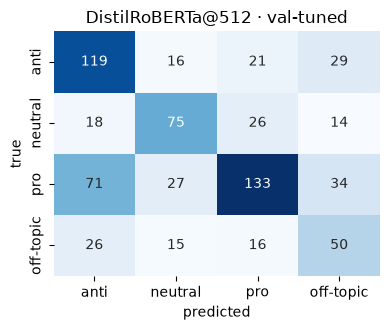

In [16]:
# Trains + saves on first run; loads on later runs (saved_models/distilroberta_stance).
dr_model, dr_tok = run_tf("DistilRoBERTa@512", "distilroberta-base", 512, 32, save_dir=DR_DIR)

## 11. Tuned validation comparison

,split,macro_f1,macro_f1_3class,accuracy,f1_anti,f1_neutral,f1_pro,f1_off-topic
model,,,,,,,,
NaiveBayes (tuned),val-tuned,0.449,0.539,0.493,0.433,0.490,0.587,0.284
XGBoost (tuned),val-tuned,0.509,0.584,0.529,0.584,0.502,0.570,0.379
ModernBERT@1024,val-tuned,0.537,0.617,0.557,0.586,0.566,0.602,0.395
DistilRoBERTa@512,val-tuned,0.534,0.600,0.546,0.568,0.564,0.577,0.427


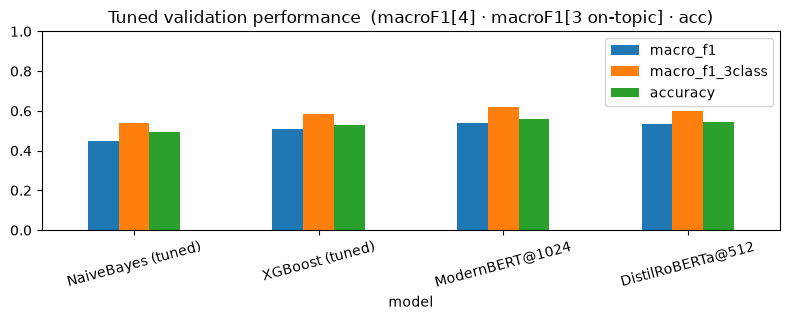

In [17]:
res_t = pd.DataFrame([r for r in RESULTS if r["split"] == "val-tuned"]).set_index("model")
display(res_t.round(3))
res_t[["macro_f1", "macro_f1_3class", "accuracy"]].plot.bar(rot=15, figsize=(8, 3.3), ylim=(0, 1))
plt.title("Tuned validation performance  (macroF1[4] · macroF1[3 on-topic] · acc)")
plt.tight_layout(); plt.show()

## 12. Final held-out test — **gated**

Runs only when `RUN_TEST = True`, and evaluates the **tuned** models (population-reweighted).
Leave it `False` while tuning so you never see test numbers until the models are frozen.


=== NaiveBayes [TEST] · TEST (pop-weighted) ===  macroF1[4]=0.265  macroF1[3 on-topic]=0.334  acc=0.304
              precision    recall  f1-score   support

        anti      0.328     0.504     0.398 1005.999459050092
     neutral      0.812     0.206     0.329 3137.7260494428133
         pro      0.152     0.584     0.242 637.2645515525263
   off-topic      0.092     0.092     0.092 350.00993995456025

    accuracy                          0.304 5130.999999999993
   macro avg      0.346     0.347     0.265 5130.999999999993
weighted avg      0.586     0.304     0.316 5130.999999999993



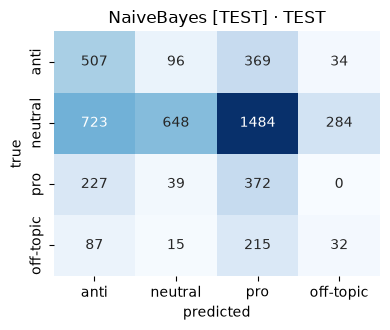


=== XGBoost [TEST] · TEST (pop-weighted) ===  macroF1[4]=0.384  macroF1[3 on-topic]=0.464  acc=0.409
              precision    recall  f1-score   support

        anti      0.455     0.672     0.542 1005.999459050092
     neutral      0.799     0.266     0.399 3137.7260494428137
         pro      0.285     0.729     0.410 637.2645515525263
   off-topic      0.126     0.349     0.185 350.00993995456025

    accuracy                          0.409 5130.999999999993
   macro avg      0.416     0.504     0.384 5130.999999999993
weighted avg      0.622     0.409     0.414 5130.999999999993



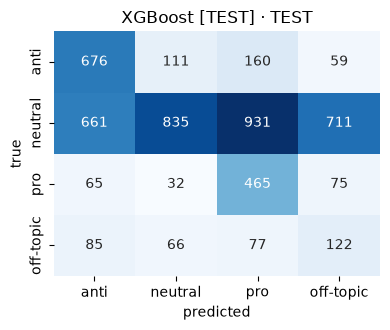


=== ModernBERT@1024 [TEST] · TEST (pop-weighted) ===  macroF1[4]=0.419  macroF1[3 on-topic]=0.466  acc=0.439
              precision    recall  f1-score   support

        anti      0.462     0.684     0.552 1005.999459050092
     neutral      0.900     0.299     0.448 3137.7260494428133
         pro      0.248     0.708     0.367 637.2645515525263
   off-topic      0.223     0.495     0.307 350.00993995456025

    accuracy                          0.439 5130.999999999993
   macro avg      0.458     0.547     0.419 5130.999999999993
weighted avg      0.687     0.439     0.449 5130.999999999993



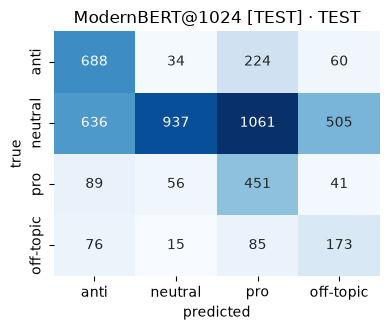


=== DistilRoBERTa@512 [TEST] · TEST (pop-weighted) ===  macroF1[4]=0.360  macroF1[3 on-topic]=0.437  acc=0.393
              precision    recall  f1-score   support

        anti      0.359     0.650     0.463 1005.999459050092
     neutral      0.839     0.270     0.409 3137.7260494428137
         pro      0.286     0.644     0.396 637.2645515525263
   off-topic      0.121     0.300     0.173 350.00993995456025

    accuracy                          0.393 5130.999999999993
   macro avg      0.401     0.466     0.360 5130.999999999993
weighted avg      0.628     0.393     0.402 5130.999999999993



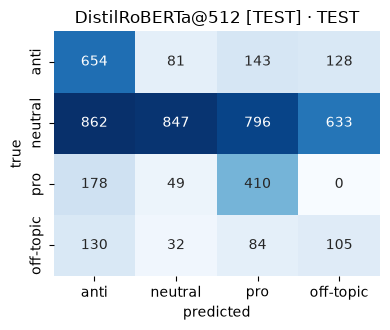

,split,macro_f1,macro_f1_3class,accuracy,f1_anti,f1_neutral,f1_pro,f1_off-topic
model,,,,,,,,
NaiveBayes [TEST],TEST,0.265,0.334,0.304,0.398,0.329,0.242,0.092
NaiveBayes [TEST],TEST,0.265,0.334,0.304,0.398,0.329,0.242,0.092
XGBoost [TEST],TEST,0.384,0.464,0.409,0.542,0.399,0.410,0.185
ModernBERT@1024 [TEST],TEST,0.419,0.466,0.439,0.552,0.448,0.367,0.307
DistilRoBERTa@512 [TEST],TEST,0.360,0.437,0.393,0.463,0.409,0.396,0.173


In [21]:
RUN_TEST = True
if not RUN_TEST:
    print("RUN_TEST = False — skipping held-out gold evaluation. Tune on validation only.")
else:
    yg, wg = gold_text["label"], gold_text["w"].to_numpy()
    for name, predict_fn in TUNED.items():
        evaluate(name + " [TEST]", "TEST", yg, predict_fn(gold_text), sample_weight=wg)
    display(pd.DataFrame([r for r in RESULTS if r["split"] == "TEST"]).set_index("model").round(3))

## Results
ModernBERT wins.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4a322346-8e1e-4650-8cef-fe9b767d96fb' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>